# Detección de Anomalías en Red

El objetivo de este análisis es identificar patrones atípicos en el tráfico de red que puedan representar amenazas. Para ello, exploraremos los datos y entrenaremos una red neuronal capaz de distinguir entre el uso normal y el anómalo.

*Basado en la guía de Amaanuddin Parvez sobre detección de anomalías con ML.*

In [7]:
!pip install pandas numpy seaborn matplotlib scikit-learn tensorflow


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [8]:
# Imports
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Configuración para asegurar resultados reproducibles
np.random.seed(42)
tf.random.set_seed(42)
plt.style.use('ggplot')

## Carga y Exploración Inicial

In [9]:
# Cargar dataset
df = pd.read_csv("data/networkanomalydataset.csv")
df.head(5)

,Inbound Rate(bit/s),Outbound Rate(bit/s),Inbound Bandwidth Utilization(%),Outbound Bandwidth Utilization(%),Label
0,0.931000,1.224246,0.931001,1.224244,0
1,0.965773,1.302733,0.965944,1.303585,0
2,1.018103,1.341763,1.017932,1.342183,0
3,1.088629,1.374144,1.088671,1.374348,0
4,1.128772,1.381435,1.128727,1.380781,0


In [10]:
df.isnull().sum()

Inbound Rate(bit/s)                  0
Outbound Rate(bit/s)                 0
Inbound Bandwidth Utilization(%)     0
Outbound Bandwidth Utilization(%)    0
Label                                0
dtype: int64

Confirmamos que el conjunto de datos está completo y no presenta valores nulos.

## Análisis Exploratorio de Datos (EDA)

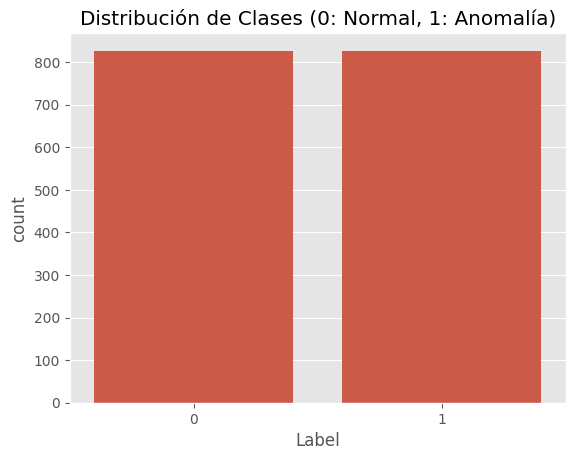

In [11]:
sns.countplot(x="Label", data=df)
plt.title('Distribución de Clases (0: Normal, 1: Anomalía)')
plt.show()

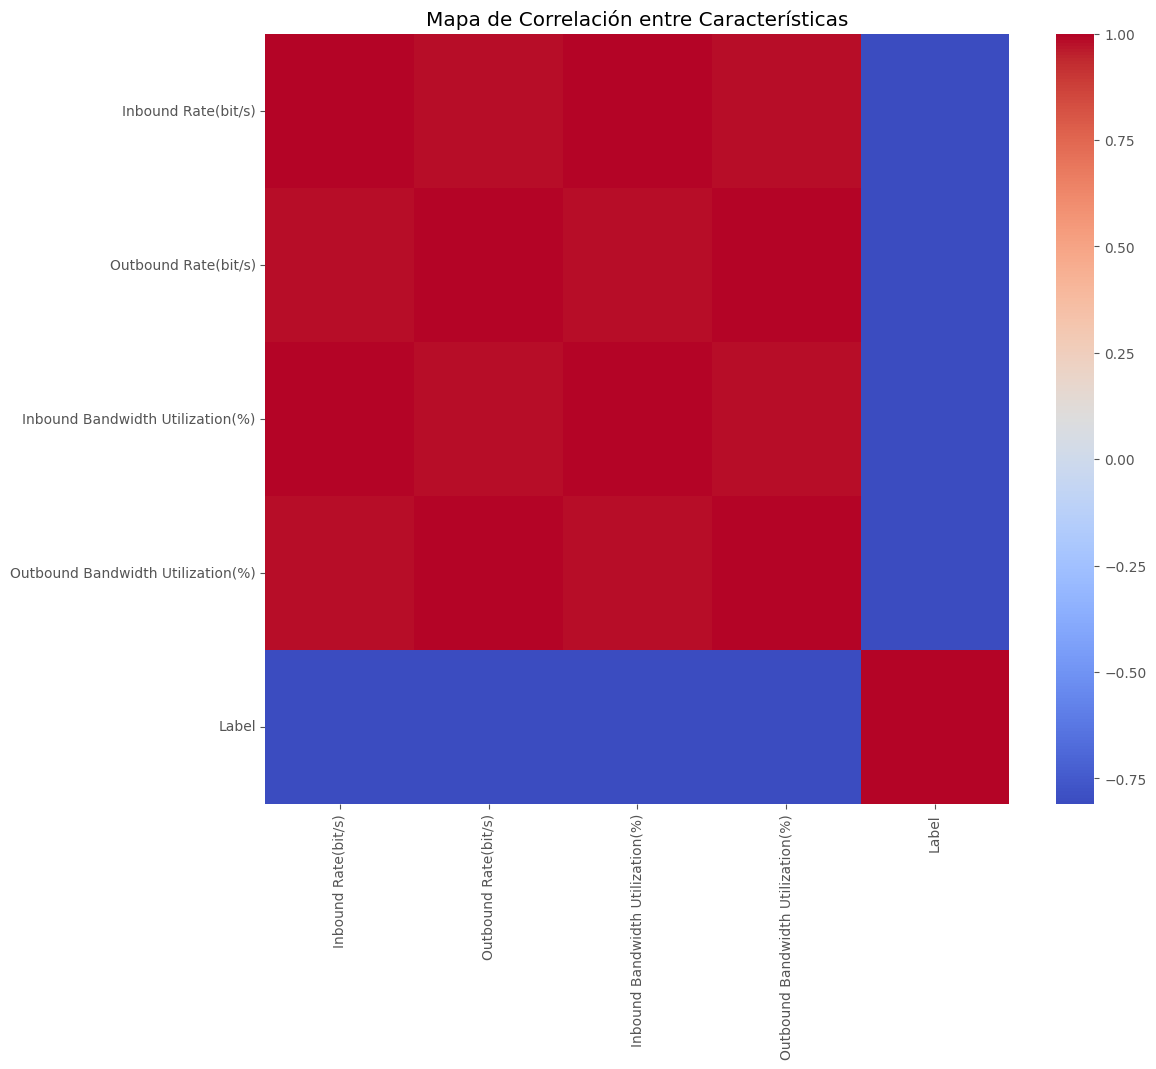

In [12]:
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(), cmap='coolwarm', annot=False)
plt.title('Mapa de Correlación entre Características')
plt.show()


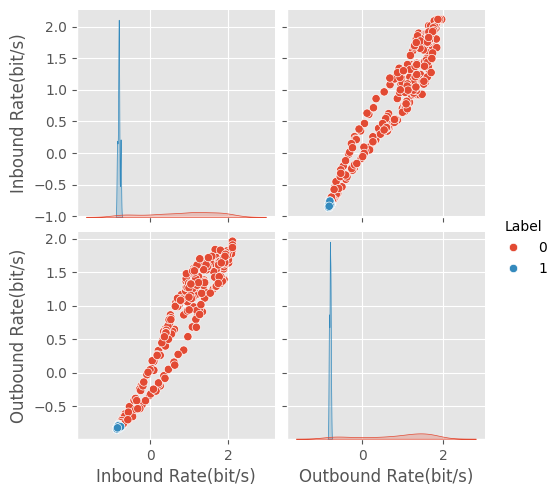

In [13]:
sampled_df = df.sample(min(500, len(df)))
sns.pairplot(sampled_df[['Inbound Rate(bit/s)', 'Outbound Rate(bit/s)', 'Label']], hue='Label')
plt.show()


## Detección de Valores Atípicos (Outliers)

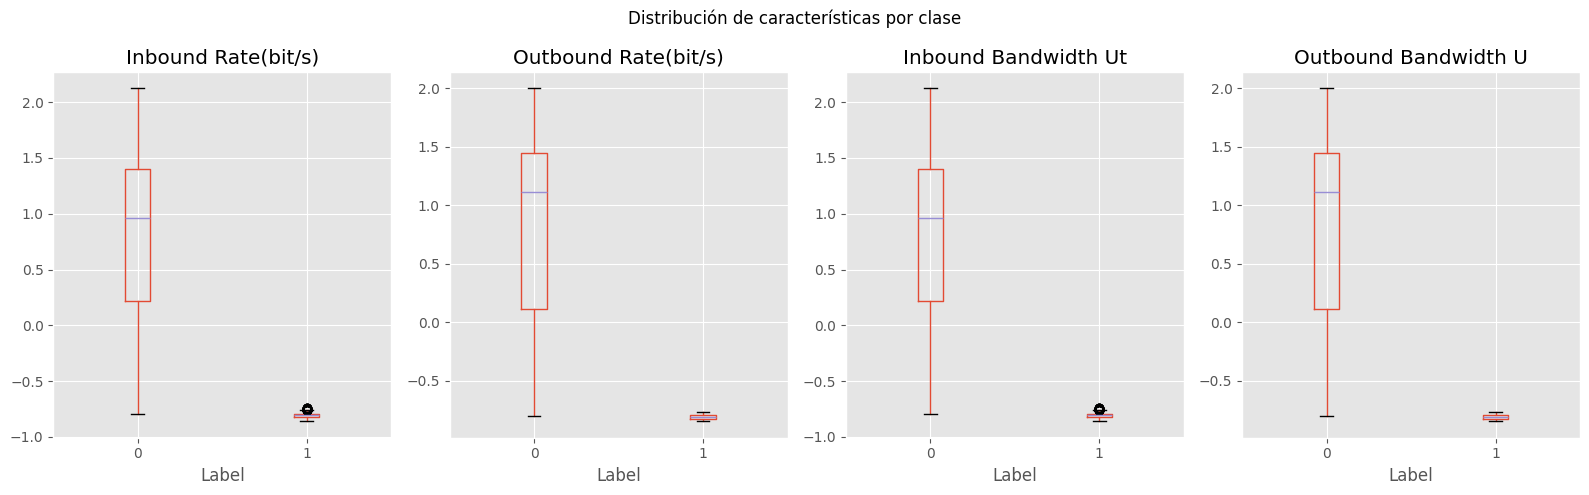

In [14]:
fig, axes = plt.subplots(1, 4, figsize=(16, 5))
for ax, col in zip(axes, df.columns):
    if col != 'Label':
        df.boxplot(column=col, by='Label', ax=ax)
        ax.set_title(col[:20])
plt.suptitle('Distribución de características por clase')
plt.tight_layout()
plt.show()

## Preprocesamiento de Datos

In [15]:
X = df.drop('Label', axis=1)
y = df['Label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

Para asegurar que todas las variables contribuyan de forma equilibrada, aplicamos **StandardScaler**. Dado que el tráfico de red presenta escalas muy dispares, este método centra los datos en cero y los ajusta según su desviación estándar. Esto favorece la estabilidad del entrenamiento y evita que las variables con rangos más amplios dominen el aprendizaje de la red.

In [16]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Diseño y Entrenamiento de la Red Neuronal

La arquitectura se diseñó siguiendo un esquema de **reducción progresiva de neuronas (64-32-16)**, lo que obliga a la red a extraer representaciones cada vez más abstractas del tráfico. 

Utilizamos **ReLU** en las capas ocultas para acelerar la convergencia y evitar el desvanecimiento del gradiente, mientras que en la salida empleamos **Sigmoid** para obtener una probabilidad directa entre 0 y 1. Además, incluimos **Dropout (0.2)** para reducir el riesgo de sobreajuste y mejorar la capacidad de generalización del modelo.

In [17]:
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

 Non-trainable params: 0 (0.00 B)

In [18]:
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stop],
    verbose=1
)

37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9806 - loss: 0.0569 - val_accuracy: 0.9759 - val_loss: 0.0723


## Evaluación del Modelo

En seguridad informática, omitir una amenaza real (Falso Negativo) es significativamente más grave que generar una falsa alarma. Por esta razón, aunque monitoreamos la precisión general, priorizamos el **Recall (Sensibilidad)**. Nuestro objetivo es capturar la mayor cantidad posible de anomalías, aceptando un margen razonable de falsos positivos en favor de una protección más robusta.

In [19]:
y_pred = (model.predict(X_test) > 0.5).astype(int)

print("Reporte de Clasificación:")
print(classification_report(y_test, y_pred))

print("Matriz de Confusión:")
print(confusion_matrix(y_test, y_pred))

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       1.00      0.95      0.98       247
           1       0.95      1.00      0.98       250

    accuracy                           0.98       497
   macro avg       0.98      0.98      0.98       497
weighted avg       0.98      0.98      0.98       497

Matriz de Confusión:
[[235  12]
 [  0 250]]


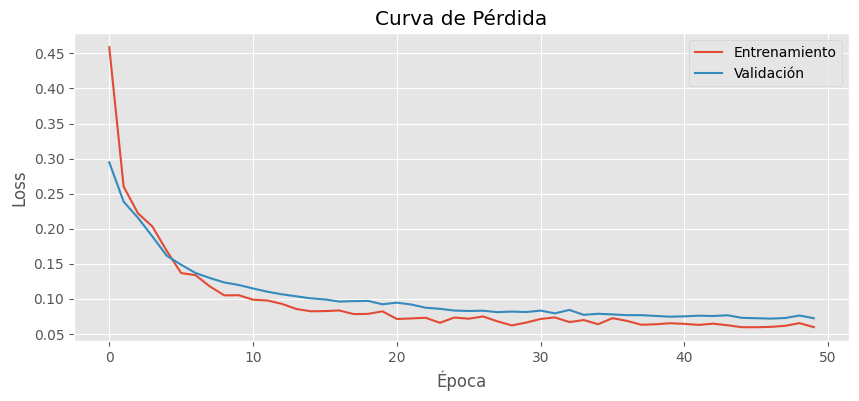

In [20]:
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'], label='Entrenamiento')
plt.plot(history.history['val_loss'], label='Validación')
plt.title('Curva de Pérdida')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()
plt.show()